In [2]:
#import the necessary things
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

In [4]:
#sets the background grid
sns.set(style='whitegrid')

In [8]:
#load the csv files
fs = pd.read_csv('unrestricted_hcp_freesurfer.csv')
beh = pd.read_csv('HCP_YA_subjects_2026_06_11_12_41_53.csv')

print('FreeSurfer:', fs.shape)
print('Behavioral:', beh.shape)

FreeSurfer: (1113, 11)
Behavioral: (1206, 15)


In [9]:
beh_no_gender = beh.drop(columns=['Gender'])
df = pd.merge(fs, beh_no_gender, on='Subject', how='inner')
print('Merged:', df.shape)

Merged: (1113, 24)


In [10]:
#check for missing data
missing = df.isna().sum()
print(missing[missing > 0])
 
key_cols = [
    'FS_L_Amygdala_Vol', 'FS_R_Amygdala_Vol',
    'FS_L_Medialorbitofrontal_GrayVol', 'FS_R_Medialorbitofrontal_GrayVol',
    'FS_L_Rostralanteriorcingulate_GrayVol', 'FS_R_Rostralanteriorcingulate_GrayVol',
    'FS_L_Medialorbitofrontal_Thck', 'FS_R_Medialorbitofrontal_Thck',
    'FS_InterCranial_Vol',
    'PercStress_Unadj', 'SelfEff_Unadj', 'AngAffect_Unadj', 'AngHostil_Unadj',
    'PercHostil_Unadj', 'PercReject_Unadj',
    'Flanker_Unadj', 'Flanker_AgeAdj', 'NEOFAC_A', 'NEOFAC_C',
    'Gender', 'Age'
]
key_cols = [c for c in key_cols if c in df.columns]
df = df.dropna(subset=key_cols).reset_index(drop=True)
print('After dropping missing:', df.shape)

AngAffect_Unadj     1
AngHostil_Unadj     1
PercHostil_Unadj    1
PercReject_Unadj    1
PercStress_Unadj    1
SelfEff_Unadj       1
NEOFAC_A            7
NEOFAC_C            7
dtype: int64
After dropping missing: (1105, 24)


In [13]:
#change the categorical variables 
df['Gender_num'] = df['Gender'].map({'M': 0, 'F': 1})
 
# Age range -> numeric midpoint (e.g. '26-30' -> 28; '36+' -> 38 as an estimate)
def age_midpoint(age_str):
    if '+' in age_str:
        return float(age_str.replace('+', '')) + 2
    lo, hi = age_str.split('-')
    return (int(lo) + int(hi)) / 2
 
df['Age_mid'] = df['Age'].apply(age_midpoint)
print(df['Age_mid'].unique())
print('NaNs in Age_mid:', df['Age_mid'].isna().sum())
 

[28.  33.  23.5 38. ]
NaNs in Age_mid: 0


In [14]:
print(df['Gender_num'].unique())
print('NaNs in Gender_num:', df['Gender_num'].isna().sum())

print(df['Age_mid'].unique())
print('NaNs in Age_mid:', df['Age_mid'].isna().sum())

# spot-check the mapping looks right
print(df[['Gender', 'Gender_num', 'Age', 'Age_mid']].drop_duplicates())

[0 1]
NaNs in Gender_num: 0
[28.  33.  23.5 38. ]
NaNs in Age_mid: 0
    Gender  Gender_num    Age  Age_mid
0        M           0  26-30     28.0
1        F           1  26-30     28.0
2        M           0  31-35     33.0
4        F           1  31-35     33.0
5        M           0  22-25     23.5
19       F           1  22-25     23.5
24       F           1    36+     38.0
413      M           0    36+     38.0


In [15]:
#Combine bilateral brain measures + normalize for head size
# ---------------------------------------------------------
df['Amygdala_Vol'] = (df['FS_L_Amygdala_Vol'] + df['FS_R_Amygdala_Vol']) / 2
df['mOFC_GrayVol'] = (df['FS_L_Medialorbitofrontal_GrayVol'] + df['FS_R_Medialorbitofrontal_GrayVol']) / 2
df['rACC_GrayVol'] = (df['FS_L_Rostralanteriorcingulate_GrayVol'] + df['FS_R_Rostralanteriorcingulate_GrayVol']) / 2
df['mOFC_Thck'] = (df['FS_L_Medialorbitofrontal_Thck'] + df['FS_R_Medialorbitofrontal_Thck']) / 2
 
df['Amygdala_Vol_norm'] = df['Amygdala_Vol'] / df['FS_InterCranial_Vol']
df['mOFC_GrayVol_norm'] = df['mOFC_GrayVol'] / df['FS_InterCranial_Vol']
df['rACC_GrayVol_norm'] = df['rACC_GrayVol'] / df['FS_InterCranial_Vol']

In [16]:
# Sanity check: averaged values should fall between L and R
print(df[['FS_L_Amygdala_Vol','FS_R_Amygdala_Vol','Amygdala_Vol']].head())

# Summary stats - check for reasonable ranges, no NaNs/negatives
print(df[['Amygdala_Vol','mOFC_GrayVol','rACC_GrayVol','mOFC_Thck',
          'Amygdala_Vol_norm','mOFC_GrayVol_norm','rACC_GrayVol_norm']].describe())

# Check no NaNs were introduced
print(df[['Amygdala_Vol_norm','mOFC_GrayVol_norm','rACC_GrayVol_norm','mOFC_Thck']].isna().sum())

   FS_L_Amygdala_Vol  FS_R_Amygdala_Vol  Amygdala_Vol
0               1734               1994        1864.0
1               1536               1658        1597.0
2               1342               1856        1599.0
3               1848               2123        1985.5
4               1524               1277        1400.5
       Amygdala_Vol  mOFC_GrayVol  rACC_GrayVol    mOFC_Thck  \
count   1105.000000   1105.000000   1105.000000  1105.000000   
mean    1597.078281   5804.725792   2738.029412     2.653571   
std      201.127480    690.800644    498.137588     0.122901   
min     1077.500000   4180.500000   1374.000000     2.042500   
25%     1452.000000   5293.000000   2396.000000     2.568500   
50%     1581.500000   5769.000000   2678.500000     2.649500   
75%     1726.000000   6233.000000   3053.000000     2.731500   
max     2407.500000   8451.000000   4499.500000     3.125500   

       Amygdala_Vol_norm  mOFC_GrayVol_norm  rACC_GrayVol_norm  
count        1105.000000        11

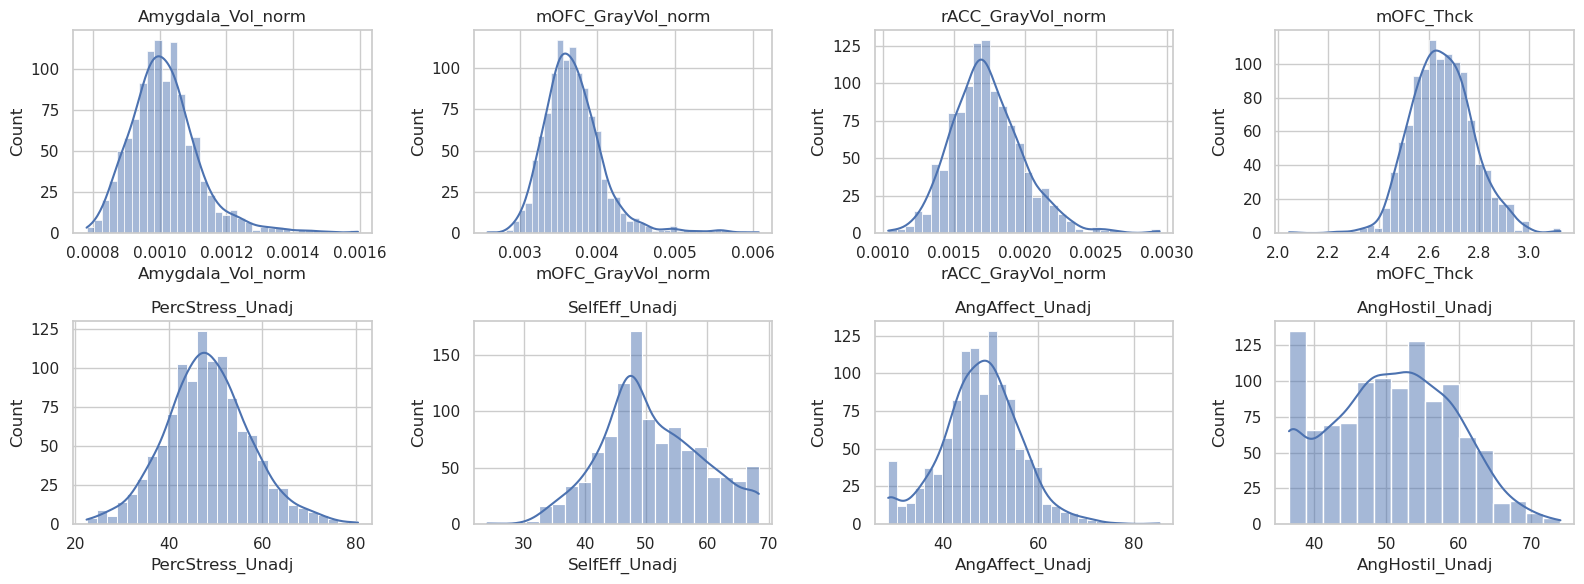

Amygdala_Vol_norm: 6 outliers (>4 SD)
mOFC_GrayVol_norm: 10 outliers (>4 SD)
rACC_GrayVol_norm: 3 outliers (>4 SD)
mOFC_Thck: 1 outliers (>4 SD)


In [20]:
# Distributions / outlier check
brain_vars = ['Amygdala_Vol_norm', 'mOFC_GrayVol_norm', 'rACC_GrayVol_norm', 'mOFC_Thck']
behav_vars = ['PercStress_Unadj', 'SelfEff_Unadj', 'AngAffect_Unadj', 'AngHostil_Unadj',
              'PercHostil_Unadj', 'PercReject_Unadj', 'Flanker_Unadj', 'Flanker_AgeAdj',
              'NEOFAC_A', 'NEOFAC_C']
 
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, col in zip(axes.flat, brain_vars + behav_vars[:4]):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()
 
for col in brain_vars:
    z = np.abs(stats.zscore(df[col]))
    n_out = (z > 4).sum()
    print(f'{col}: {n_out} outliers (>4 SD)')
 
#drop extreme outliers:
df = df[(np.abs(stats.zscore(df[brain_vars])) < 4).all(axis=1)]
 

In [22]:
#standardise Z scores
z_cols = brain_vars + behav_vars + ['Age_mid']
for col in z_cols:
    df[col + '_z'] = stats.zscore(df[col])
 

In [23]:
#check that Zscores were calculated properly
# Check that all _z columns exist
z_cols_check = [c + '_z' for c in (brain_vars + behav_vars + ['Age_mid'])]
print(z_cols_check)
print([c in df.columns for c in z_cols_check])

# z-scored columns should have mean ~0 and std ~1
print(df[z_cols_check].describe().loc[['mean', 'std']])

# No NaNs introduced
print(df[z_cols_check].isna().sum())

# Spot-check: original vs z-scored for one variable
print(df[['PercStress_Unadj', 'PercStress_Unadj_z']].head())

['Amygdala_Vol_norm_z', 'mOFC_GrayVol_norm_z', 'rACC_GrayVol_norm_z', 'mOFC_Thck_z', 'PercStress_Unadj_z', 'SelfEff_Unadj_z', 'AngAffect_Unadj_z', 'AngHostil_Unadj_z', 'PercHostil_Unadj_z', 'PercReject_Unadj_z', 'Flanker_Unadj_z', 'Flanker_AgeAdj_z', 'NEOFAC_A_z', 'NEOFAC_C_z', 'Age_mid_z']
[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]
      Amygdala_Vol_norm_z  mOFC_GrayVol_norm_z  rACC_GrayVol_norm_z  \
mean        -2.187792e-16        -4.285787e-16        -9.796086e-18   
std          1.000460e+00         1.000460e+00         1.000460e+00   

       mOFC_Thck_z  PercStress_Unadj_z  SelfEff_Unadj_z  AngAffect_Unadj_z  \
mean  1.387779e-15        6.669502e-16     9.347098e-16      -9.224647e-17   
std   1.000460e+00        1.000460e+00     1.000460e+00       1.000460e+00   

      AngHostil_Unadj_z  PercHostil_Unadj_z  PercReject_Unadj_z  \
mean       1.632681e-18       -6.987874e-16        3.885781e-16   
std        1.000460e+00        1.0

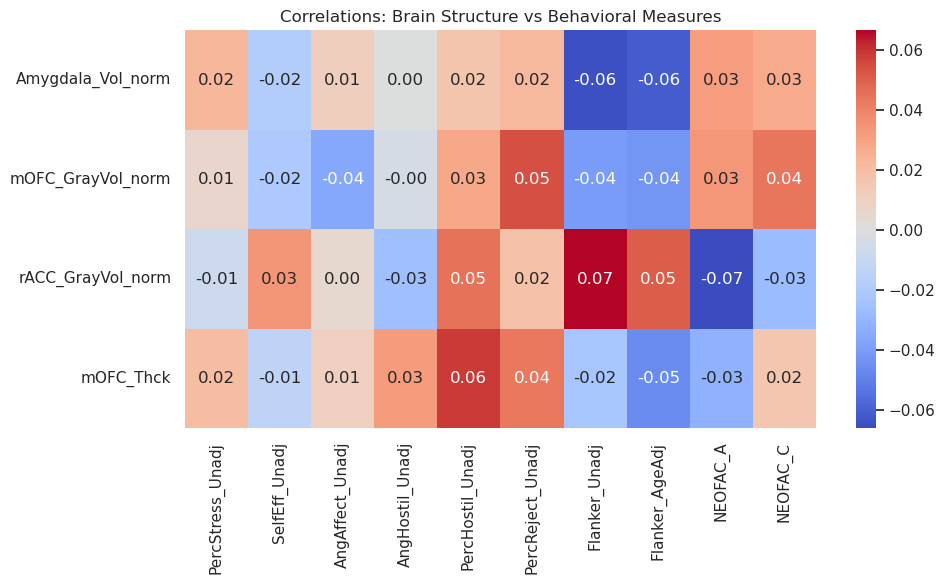

In [24]:
#correlation matrix
corr_df = df[brain_vars + behav_vars]
corr_matrix = corr_df.corr()
 
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix.loc[brain_vars, behav_vars], annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlations: Brain Structure vs Behavioral Measures')
plt.tight_layout()
plt.show()

Based on the correlation heatmap, all correlations between brain structure and behavioral measures are very weak (|r| <= 0.07). The largest are:
- rACC_GrayVol_norm vs Flanker_Unadj (r ~ 0.07)
- rACC_GrayVol_norm vs NEOFAC_A (r ~ -0.07)
- Amygdala_Vol_norm vs Flanker_Unadj / Flanker_AgeAdj (r ~ -0.06)

Howevern it is important to note that with around 1100 subjects, r ~ 0.06-0.07 while it might be statistically significant, it would explain less than 1% variance and would likely be a weak/null pattern that does not meaningfully explain brain-behaviour links. 

In [25]:
#since there are 40 pairs we would use benjamini hochberg fdr correction
from itertools import product
from statsmodels.stats.multitest import multipletests
 
results = []
for b_var, beh_var in product(brain_vars, behav_vars):
    r, p = stats.pearsonr(df[b_var], df[beh_var])
    results.append({'brain_var': b_var, 'behav_var': beh_var, 'r': r, 'r_squared': r**2, 'p': p})
 
corr_results = pd.DataFrame(results)
 
reject, p_fdr, _, _ = multipletests(corr_results['p'], alpha=0.05, method='fdr_bh')
corr_results['p_fdr'] = p_fdr
corr_results['significant_fdr'] = reject
 
print(corr_results.sort_values('p').head(10))
print('\nNumber of pairs surviving FDR correction (q < 0.05):', corr_results['significant_fdr'].sum())

            brain_var         behav_var         r  r_squared         p  \
26  rACC_GrayVol_norm     Flanker_Unadj  0.066517   0.004425  0.028238   
28  rACC_GrayVol_norm          NEOFAC_A -0.066271   0.004392  0.028829   
6   Amygdala_Vol_norm     Flanker_Unadj -0.064793   0.004198  0.032600   
7   Amygdala_Vol_norm    Flanker_AgeAdj -0.061180   0.003743  0.043634   
34          mOFC_Thck  PercHostil_Unadj  0.058492   0.003421  0.053756   
15  mOFC_GrayVol_norm  PercReject_Unadj  0.053976   0.002913  0.075135   
27  rACC_GrayVol_norm    Flanker_AgeAdj  0.050734   0.002574  0.094402   
37          mOFC_Thck    Flanker_AgeAdj -0.046368   0.002150  0.126385   
24  rACC_GrayVol_norm  PercHostil_Unadj  0.045038   0.002028  0.137645   
19  mOFC_GrayVol_norm          NEOFAC_C  0.044162   0.001950  0.145473   

       p_fdr  significant_fdr  
26  0.430048            False  
28  0.430048            False  
6   0.430048            False  
7   0.430048            False  
34  0.430048            F

We also constructed a composite by averaging the z-scored values of AngAffect_Unadj, AngHostil_Unadj, PercHostil_Unadj, and PercReject_Unadj. These four measures were selected a priori as related facets of trait anger and hostile social perception — they are not a validated "aggression" scale, but a composite proxy capturing a shared dimension of angry affect and perceived interpersonal hostility.

In [26]:
aggression_proxies = ['AngAffect_Unadj_z', 'AngHostil_Unadj_z', 'PercHostil_Unadj_z', 'PercReject_Unadj_z']

In [27]:
print('\nCorrelations among aggression proxy variables:')
print(df[aggression_proxies].corr())


Correlations among aggression proxy variables:
                    AngAffect_Unadj_z  AngHostil_Unadj_z  PercHostil_Unadj_z  \
AngAffect_Unadj_z            1.000000           0.432084            0.484561   
AngHostil_Unadj_z            0.432084           1.000000            0.361218   
PercHostil_Unadj_z           0.484561           0.361218            1.000000   
PercReject_Unadj_z           0.454926           0.440453            0.608699   

                    PercReject_Unadj_z  
AngAffect_Unadj_z             0.454926  
AngHostil_Unadj_z             0.440453  
PercHostil_Unadj_z            0.608699  
PercReject_Unadj_z            1.000000  


The above variables are moderately related to each other.

In [29]:
#composite z scores
df['Aggression_composite'] = df[aggression_proxies].mean(axis=1)

In [30]:
agg_results = []
for b_var in brain_vars:
    r, p = stats.pearsonr(df[b_var], df['Aggression_composite'])
    agg_results.append({'brain_var': b_var, 'r': r, 'r_squared': r**2, 'p': p})
 
agg_results = pd.DataFrame(agg_results)
reject_agg, p_fdr_agg, _, _ = multipletests(agg_results['p'], alpha=0.05, method='fdr_bh')
agg_results['p_fdr'] = p_fdr_agg
agg_results['significant_fdr'] = reject_agg
 
print('\nBrain structure vs Aggression composite:')
print(agg_results)


Brain structure vs Aggression composite:
           brain_var         r  r_squared         p     p_fdr  significant_fdr
0  Amygdala_Vol_norm  0.015957   0.000255  0.599050  0.652140            False
1  mOFC_GrayVol_norm  0.013867   0.000192  0.647747  0.652140            False
2  rACC_GrayVol_norm  0.013682   0.000187  0.652140  0.652140            False
3          mOFC_Thck  0.046862   0.002196  0.122392  0.489568            False
